In [19]:
# BCG GenAI Job Simulation – Task 1

## Financial Data Analysis of Microsoft, Apple, and Tesla (2023–2025)

In [1]:
!mamba install pandas

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.0366000000014903 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [2]:
import pandas as pd
df = pd.read_csv("financial_data.csv")
print(df)
print(df.shape)
df

     Company  Year  Total Revenue  Net Income  Total Assets  \
0  Microsoft  2025         281724      101832        619003   
1  Microsoft  2024         245122       88136        512163   
2  Microsoft  2023         211915       72361        411976   
3      Apple  2025         416161      112010        359241   
4      Apple  2024         391035       93736        364980   
5      Apple  2023         383285       96995        352583   
6      Tesla  2025          94827        3794        137806   
7      Tesla  2024          97690        7091        122070   
8      Tesla  2023          96773       14997        106618   

   Total Liabilities  Operating Cash Flow  
0             275524               136162  
1             243686               118548  
2             205753                87582  
3             285508               111482  
4             308030               118254  
5             290437               110543  
6              54941                14747  
7              48

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow
0,Microsoft,2025,281724,101832,619003,275524,136162
1,Microsoft,2024,245122,88136,512163,243686,118548
2,Microsoft,2023,211915,72361,411976,205753,87582
3,Apple,2025,416161,112010,359241,285508,111482
4,Apple,2024,391035,93736,364980,308030,118254
5,Apple,2023,383285,96995,352583,290437,110543
6,Tesla,2025,94827,3794,137806,54941,14747
7,Tesla,2024,97690,7091,122070,48390,14923
8,Tesla,2023,96773,14997,106618,43009,13256


In [3]:
# Year-over-Year Growth Calculation

df["Revenue Growth (%)"] = (df.groupby("Company")["Total Revenue"].pct_change() * 100)

df["Net Income Growth (%)"] = (df.groupby("Company")["Net Income"].pct_change() * 100)

df["Assets Growth (%)"] = (df.groupby("Company")["Total Assets"].pct_change() * 100)

df["Liabilities Growth (%)"] = (df.groupby("Company")["Total Liabilities"].pct_change() * 100)

df["Operating Cash Flow Growth (%)"] = (df.groupby("Company")["Operating Cash Flow"].pct_change() * 100)

df.round(2)

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
0,Microsoft,2025,281724,101832,619003,275524,136162,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,245122,88136,512163,243686,118548,-12.99,-13.45,-17.26,-11.56,-12.94
2,Microsoft,2023,211915,72361,411976,205753,87582,-13.55,-17.90,-19.56,-15.57,-26.12
3,Apple,2025,416161,112010,359241,285508,111482,NaN,NaN,NaN,NaN,NaN
4,Apple,2024,391035,93736,364980,308030,118254,-6.04,-16.31,1.60,7.89,6.07
5,Apple,2023,383285,96995,352583,290437,110543,-1.98,3.48,-3.40,-5.71,-6.52
6,Tesla,2025,94827,3794,137806,54941,14747,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,97690,7091,122070,48390,14923,3.02,86.90,-11.42,-11.92,1.19
8,Tesla,2023,96773,14997,106618,43009,13256,-0.94,111.49,-12.66,-11.12,-11.17


In [4]:
# Summary Statistics

df.describe()

,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2024.000000,246503.555556,65661.333333,331826.666667,195030.888889,80610.777778,-5.413045,25.701317,-10.449652,-7.998101,-8.246754
std,0.866025,131525.376877,44160.818793,178905.593674,113610.100337,51270.531241,6.736337,57.963122,8.125334,8.398803,11.377397
min,2023.000000,94827.000000,3794.000000,106618.000000,43009.000000,13256.000000,-13.547132,-17.898475,-19.561546,-15.566344,-26.121065
25%,2023.000000,97690.000000,14997.000000,137806.000000,54941.000000,14923.000000,-11.253503,-15.598362,-16.109588,-11.831634,-12.494715
50%,2024.000000,245122.000000,88136.000000,359241.000000,243686.000000,110543.000000,-4.009743,-4.986409,-12.038631,-11.337751,-8.845693
75%,2025.000000,383285.000000,96995.000000,411976.000000,285508.000000,118254.000000,-1.199493,66.044473,-5.402206,-7.063609,-0.735080
max,2025.000000,416161.000000,112010.000000,619003.000000,308030.000000,136162.000000,3.019182,111.493442,1.597535,7.888395,6.074523


In [5]:
# Company-wise Average

df.groupby("Company").mean(numeric_only=True)

,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
Company,,,,,,,,,,,
Apple,2024.0,396827.000000,100913.666667,358934.666667,294658.333333,113426.333333,-4.009743,-6.418914,-0.899545,1.088469,-0.223093
Microsoft,2024.0,246253.666667,87443.000000,514380.666667,241654.333333,114097.333333,-13.269640,-15.674039,-18.410780,-13.560890,-19.528563
Tesla,2024.0,96430.000000,8627.333333,122164.666667,48780.000000,14308.666667,1.040249,99.196906,-12.038631,-11.521883,-4.988607


In [6]:
# Check missing values
df.isnull().sum()

Company                           0
Year                              0
Total Revenue                     0
Net Income                        0
Total Assets                      0
Total Liabilities                 0
Operating Cash Flow               0
Revenue Growth (%)                3
Net Income Growth (%)             3
Assets Growth (%)                 3
Liabilities Growth (%)            3
Operating Cash Flow Growth (%)    3
dtype: int64

In [7]:
#Data types
df.dtypes

Company                               str
Year                                int64
Total Revenue                       int64
Net Income                          int64
Total Assets                        int64
Total Liabilities                   int64
Operating Cash Flow                 int64
Revenue Growth (%)                float64
Net Income Growth (%)             float64
Assets Growth (%)                 float64
Liabilities Growth (%)            float64
Operating Cash Flow Growth (%)    float64
dtype: object

In [ ]:
# Revenue Growth
df["Revenue Growth (%)"] = df.groupby("Company")["Total Revenue"].pct_change() * 100

In [ ]:
# Net Income Growth
df["Net Income Growth (%)"] = df.groupby("Company")["Net Income"].pct_change() * 100

In [ ]:
# Assets Growth
df["Assets Growth (%)"] = df.groupby("Company")["Total Assets"].pct_change() * 100

In [ ]:
# Liabilities Growth
df["Liabilities Growth (%)"] = df.groupby("Company")["Total Liabilities"].pct_change() * 100

In [ ]:
# Operating Cash Flow Growth
df["Operating Cash Flow Growth (%)"] = (df.groupby("Company")["Operating Cash Flow"].pct_change() * 100)

In [8]:
df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
0,Microsoft,2025,281724,101832,619003,275524,136162,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,245122,88136,512163,243686,118548,-12.992148,-13.449603,-17.260013,-11.555436,-12.936061
2,Microsoft,2023,211915,72361,411976,205753,87582,-13.547132,-17.898475,-19.561546,-15.566344,-26.121065
3,Apple,2025,416161,112010,359241,285508,111482,NaN,NaN,NaN,NaN,NaN
4,Apple,2024,391035,93736,364980,308030,118254,-6.037567,-16.314615,1.597535,7.888395,6.074523
5,Apple,2023,383285,96995,352583,290437,110543,-1.981920,3.476786,-3.396624,-5.711457,-6.520710
6,Tesla,2025,94827,3794,137806,54941,14747,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,97690,7091,122070,48390,14923,3.019182,86.900369,-11.418951,-11.923700,1.193463
8,Tesla,2023,96773,14997,106618,43009,13256,-0.938684,111.493442,-12.658311,-11.120066,-11.170676


In [9]:
df = df.sort_values(["Company", "Year"])
df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
5,Apple,2023,383285,96995,352583,290437,110543,-1.981920,3.476786,-3.396624,-5.711457,-6.520710
4,Apple,2024,391035,93736,364980,308030,118254,-6.037567,-16.314615,1.597535,7.888395,6.074523
3,Apple,2025,416161,112010,359241,285508,111482,NaN,NaN,NaN,NaN,NaN
2,Microsoft,2023,211915,72361,411976,205753,87582,-13.547132,-17.898475,-19.561546,-15.566344,-26.121065
1,Microsoft,2024,245122,88136,512163,243686,118548,-12.992148,-13.449603,-17.260013,-11.555436,-12.936061
0,Microsoft,2025,281724,101832,619003,275524,136162,NaN,NaN,NaN,NaN,NaN
8,Tesla,2023,96773,14997,106618,43009,13256,-0.938684,111.493442,-12.658311,-11.120066,-11.170676
7,Tesla,2024,97690,7091,122070,48390,14923,3.019182,86.900369,-11.418951,-11.923700,1.193463
6,Tesla,2025,94827,3794,137806,54941,14747,NaN,NaN,NaN,NaN,NaN


In [10]:
df["Revenue Growth (%)"] = df.groupby("Company")["Total Revenue"].pct_change() * 100

df["Net Income Growth (%)"] = df.groupby("Company")["Net Income"].pct_change() * 100

df["Assets Growth (%)"] = df.groupby("Company")["Total Assets"].pct_change() * 100

df["Liabilities Growth (%)"] = df.groupby("Company")["Total Liabilities"].pct_change() * 100

df["Operating Cash Flow Growth (%)"] = (df.groupby("Company")["Operating Cash Flow"].pct_change() * 100)

df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
5,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
4,Apple,2024,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516052,6.057424,6.975566
3,Apple,2025,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656
2,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.436183,35.356580
0,Microsoft,2025,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
8,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,97690,7091,122070,48390,14923,0.947578,-52.717210,14.492862,12.511335,12.575438
6,Tesla,2025,94827,3794,137806,54941,14747,-2.930699,-46.495558,12.890964,13.537921,-1.179388


In [11]:
df = df.sort_values(["Company", "Year"], ascending=[True, False])
df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
3,Apple,2025,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656
4,Apple,2024,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516052,6.057424,6.975566
5,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
0,Microsoft,2025,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
1,Microsoft,2024,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.436183,35.356580
2,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
6,Tesla,2025,94827,3794,137806,54941,14747,-2.930699,-46.495558,12.890964,13.537921,-1.179388
7,Tesla,2024,97690,7091,122070,48390,14923,0.947578,-52.717210,14.492862,12.511335,12.575438
8,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN


In [12]:
df.head()

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
3,Apple,2025,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656
4,Apple,2024,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516052,6.057424,6.975566
5,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
0,Microsoft,2025,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
1,Microsoft,2024,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.436183,35.356580


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 3 to 8
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Company                         9 non-null      str    
 1   Year                            9 non-null      int64  
 2   Total Revenue                   9 non-null      int64  
 3   Net Income                      9 non-null      int64  
 4   Total Assets                    9 non-null      int64  
 5   Total Liabilities               9 non-null      int64  
 6   Operating Cash Flow             9 non-null      int64  
 7   Revenue Growth (%)              6 non-null      float64
 8   Net Income Growth (%)           6 non-null      float64
 9   Assets Growth (%)               6 non-null      float64
 10  Liabilities Growth (%)          6 non-null      float64
 11  Operating Cash Flow Growth (%)  6 non-null      float64
dtypes: float64(5), int64(6), str(1)
memory usage: 900.0 byte

In [14]:
df.describe()

,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Assets Growth (%),Liabilities Growth (%),Operating Cash Flow Growth (%)
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2024.000000,246503.555556,65661.333333,331826.666667,195030.888889,80610.777778,6.177751,-7.622920,12.417777,9.382735,10.476609
std,0.866025,131525.376877,44160.818793,178905.593674,113610.100337,51270.531241,7.673226,33.765003,9.923781,9.081171,14.514000
min,2023.000000,94827.000000,3794.000000,106618.000000,43009.000000,13256.000000,-2.930699,-52.717210,-1.572415,-7.311625,-5.726656
25%,2023.000000,97690.000000,14997.000000,137806.000000,54941.000000,14923.000000,1.216182,-35.711660,5.859780,7.670902,0.859351
50%,2024.000000,245122.000000,88136.000000,359241.000000,243686.000000,110543.000000,4.223753,6.089827,13.691913,12.788254,9.775502
75%,2025.000000,383285.000000,96995.000000,411976.000000,285508.000000,118254.000000,12.805495,18.506289,19.268625,13.419734,14.287447
max,2025.000000,416161.000000,112010.000000,619003.000000,308030.000000,136162.000000,15.669962,21.800417,24.318650,18.436183,35.356580


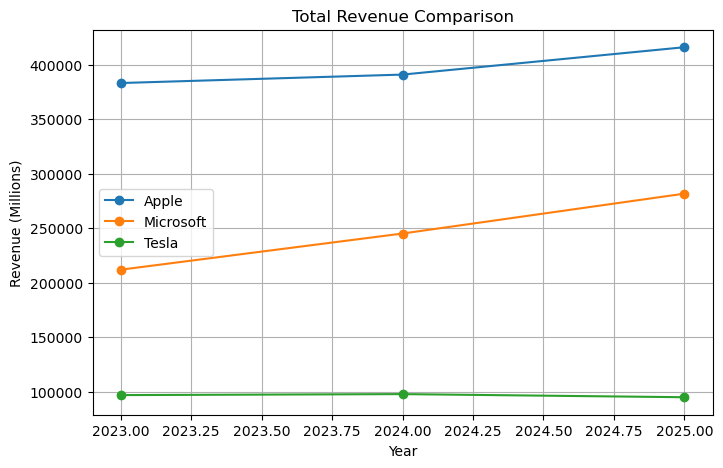

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for company in df["Company"].unique():
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Year"], company_data["Total Revenue"], marker="o", label=company)

plt.title("Total Revenue Comparison")
plt.xlabel("Year")
plt.ylabel("Revenue (Millions)")
plt.legend()
plt.grid(True)

plt.show()

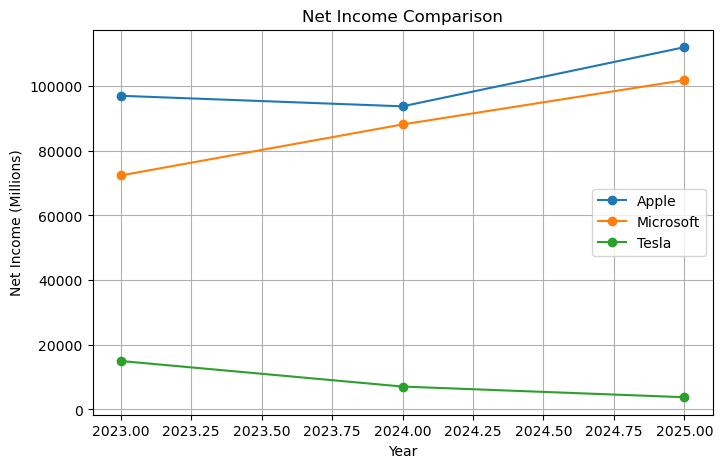

In [16]:
plt.figure(figsize=(8,5))

for company in df["Company"].unique():
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Year"], company_data["Net Income"], marker="o", label=company)

plt.title("Net Income Comparison")
plt.xlabel("Year")
plt.ylabel("Net Income (Millions)")
plt.legend()
plt.grid(True)

plt.show()

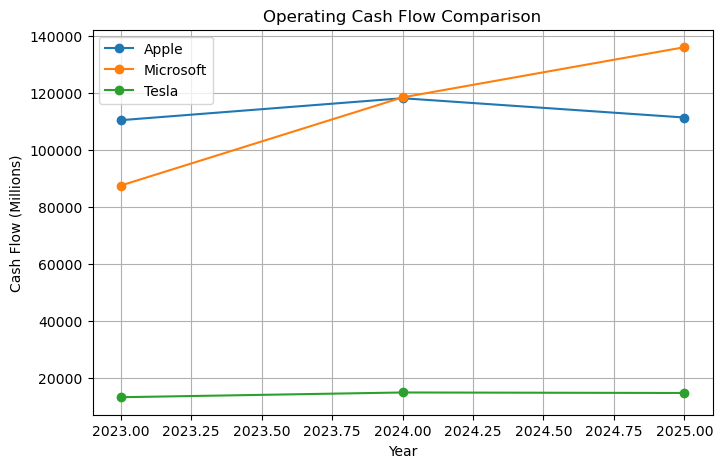

In [17]:
plt.figure(figsize=(8,5))

for company in df["Company"].unique():
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Year"], company_data["Operating Cash Flow"], marker="o", label=company)

plt.title("Operating Cash Flow Comparison")
plt.xlabel("Year")
plt.ylabel("Cash Flow (Millions)")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
df.to_csv("financial_data_cleaned.csv", index=False)
print("File saved successfully!")

File saved successfully!
